In [1]:
import  jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
x_lb = 0 
x_rb = 1
d = 2
n = 6
N_x =2**n
dt = 1e-3
steps=100
A = np.array(
    [
        [1, 0.], 
        [0., 1.]
    ]
)


In [2]:
L = x_rb - x_lb
dx = L/N_x
y_lb = x_lb
y_ub = x_rb
N_y = N_x
xs, ys = np.meshgrid(np.linspace(x_lb, x_rb, N_x, endpoint=False), 
                    np.linspace(y_lb, y_ub, N_y, endpoint=False), 
                    indexing='ij')

In [3]:
import jax

@jax.vmap
@jax.vmap
def A_vec(u):
    return A@ u

@jax.vmap
@jax.vmap
def vec_dot(u, v):
    return jnp.dot(u, v)

def energy(u, f,N):

    u_h = jnp.fft.rfft2(u)
    wave = jnp.fft.fftfreq(N, d= dx) * 2j* np.pi
    wave_real = jnp.fft.rfftfreq(N, d= dx)* 2j* np.pi
    k_x, k_y = jnp.meshgrid(wave, wave_real, indexing='ij')
    u_x_h = k_x * u_h
    u_y_h = k_y * u_h
    u_x = jnp.fft.irfft2(u_x_h, s=(N, N))
    u_y = jnp.fft.irfft2(u_y_h, s=(N, N))
    u_grad = jnp.stack([u_x, u_y], axis=-1)
    Au_vec = A_vec(u_grad)

    return jnp.mean(vec_dot(Au_vec, u_grad)/2 + f*u).real


In [4]:
def f(x, y) : 
    return np.cos(2*np.pi *x) * np.sin(-4*np.pi * y )
def u_init(x, y): 
    return np.cos(2*np.pi *x) * np.sin(8*np.pi *y) + 2 * np.sin(6*np.pi*y) + 3 * np.sin(10*np.pi *x) * np.cos(12 * np.pi *y)**2

In [5]:
def spectral_eigenvalues(N, L=1.0):
    """Eigenvalues of the 1D derivative operator with periodic condition."""
    k = np.fft.fftfreq(N, d=L/N) * 2j * np.pi  # frequency vector
    return k  

In [6]:

"""Constructs the 1D DFT matrix of size N."""
dfmtx = np.fft.fft(np.eye(N_x))#/np.sqrt(N_x)

"""Constructs the 2D DFT matrix of size N x N as a Kronecker product."""
FG = np.kron(dfmtx, dfmtx)
GF = np.kron(
    (np.conj(dfmtx).T)/N_x, 
    (np.conj(dfmtx).T)/N_x, 
)

In [7]:
def iterative_heat(u_n, f,N, dt=dt): 

    u_h = np.fft.rfft2(u_n)
    f_h = np.fft.rfft2(f)

    RHS =  u_h - dt* f_h

    # Invert (\Id - dt \Delta)    
    wave = np.fft.fftfreq(N, d= dx) * 2j* np.pi
    wave_real = np.fft.rfftfreq(N, d= dx)* 2j* np.pi
    k_x, k_y = np.meshgrid(wave, wave_real, indexing='ij')
    diffuse_u_h = (A[0,0]*k_x**2 + + A[1,0] * k_x * k_y + A[0, 1] * k_y * k_x + A[1,1]*k_y**2)
    ones = np.ones_like(diffuse_u_h)
    
    midstep=(ones - dt* diffuse_u_h)
    u_next_h = RHS/midstep
    
    return  np.fft.irfft2(u_next_h, s= (N, N))

In [8]:
def spectralFilter(N, dt=1e-3):
    d = spectral_eigenvalues(N)
    D= np.diag(d)
    Diffuse_h = A[0,0]*np.kron(D**2, np.eye(N)) + A[0, 1] * np.kron(D, D) + A[1, 0] * np.kron(D, D) + A[1, 1]*np.kron(np.eye(N), D**2)
    
    op_h = np.kron(np.eye(N), np.eye(N) ) - dt *Diffuse_h 
    return np.linalg.inv(op_h)

def iterative_heat_FG(u_val, f_val, dt): 
    N = u_val.shape[0]
    u_flatten = u_val.flatten()
    f_flatten = f_val.flatten()

    #print(f_flatten)
    u_h = FG @ u_flatten
    f_h = FG @ f_flatten
    #print("RHS: ", u_h - dt * f_h)
    u_new = GF @ spectralFilter(N, dt) @ (u_h - dt * f_h)


    return u_new.reshape(N_x, N_y)



In [9]:
import numpy as np
from scipy.linalg import sqrtm, dft
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
def make_unitary(A):
    N = A.shape[0]
    sqrt_term = sqrtm(np.eye(N) - A.conj().T @ A)
    return np.block([
        [A,         sqrt_term],
        [sqrt_term, -A       ]
    ])




# ── Quantum circuit ────────────────────────────────────────────────────────────

def build_circuit(inverse_Elliptic, n):

    total_qubits = 2 * n + 1
    # Normalise so that A / alpha has spectral norm ≤ 1
    alpha    = np.linalg.norm(inverse_Elliptic)
    A_normed = inverse_Elliptic / alpha

    U = make_unitary(A_normed)
  
    qft  = QFT(n)
    qft1 = QFT(n)

    qc = QuantumCircuit(total_qubits)
    qc.append(qft,          list(range(n)))
    qc.append(qft1,         list(range(n, 2 * n)))
    qc.unitary(U,           list(range(total_qubits)))
    qc.append(qft.inverse(),  list(range(n)))
    qc.append(qft1.inverse(), list(range(n, 2 * n)))

    return qc, alpha


def extract_unitary(qc):
    """Simulates the circuit and returns its full unitary matrix."""
    print("  Simulating unitary...")
    qc_sim = qc.copy()
    qc_sim.save_unitary()
    sim    = AerSimulator(method="unitary")
    qc_sim = transpile(qc_sim, sim)
    result = sim.run(qc_sim).result()
    return np.array(result.get_unitary(qc_sim))



In [10]:
def iterative_heat_QC2(u_n, f,mat,N, dt=dt): 
    v_n = u_n -dt*f
    v_n = v_n.reshape(N**2, 1)
    normalized_input = (v_n) / np.linalg.norm(v_n)
    #print(normalized_input.shape, mat[:N**2, :N**2].shape)
    u_next = mat[:N**2, :N**2] @ (normalized_input)*np.linalg.norm(v_n)
    return  u_next.reshape(N, N)

def iterative_heat_QC(u_n, f, dt=dt): 
    v_n = u_n -dt*f
    v_n = v_n.reshape(N_x**2, 1)
    normalized_input = (v_n) / np.linalg.norm(v_n)
    #print(normalized_input.shape, mat[:N**2, :N**2].shape)
    u_next = leading_block @ (alpha * normalized_input)*np.linalg.norm(v_n)
    return  u_next.reshape(N_x, N_x)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker

def plot_solutions_and_errors(n, N, xs, ys, u_classical, u_FG, u_quantum, STEPS, DT, save_path=None):
    """
    2x3 panel using Viridis for all plots, shared aligned colorbars,
    and shrunken scientific notation text.
    """
    err_FG = np.abs(u_FG - u_classical)
    err_QC = np.abs(u_quantum - u_classical)

    vmin_u, vmax_u = min(u_classical.min(), u_FG.min(), u_quantum.min()), max(u_classical.max(), u_FG.max(), u_quantum.max())
    vmax_e = max(err_FG.max(), err_QC.max()) or 1.0
    ext = [xs.min(), xs.max(), ys.min(), ys.max()]

    # All elements now use Viridis
    kw_sol = dict(origin='lower', vmin=vmin_u, vmax=vmax_u, extent=ext, cmap='viridis', aspect='equal')
    kw_err = dict(origin='lower', vmin=0, vmax=vmax_e, extent=ext, cmap='viridis', aspect='equal')

    fig = plt.figure(figsize=(14, 7))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.2)

    # --- Row 1: Solutions ---
    titles_row1 = ['Reference', 'Classical solution', 'Quantum solution']
    sols = [u_classical, u_FG, u_quantum]
    
    for col in range(3):
        ax = fig.add_subplot(gs[0, col])
        im = ax.imshow(sols[col].T, **kw_sol)
        ax.set_title(titles_row1[col], fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        
        if col == 2:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            cb = fig.colorbar(im, cax=cax, format='%.2f')
            cb.ax.tick_params(labelsize=8)

    # --- Row 2: Errors ---
    fig.add_subplot(gs[1, 0]).axis('off')

    titles_row2 = ['Classical error', 'Quantum error']
    errs = [err_FG, err_QC]

    for i, col in enumerate(range(1, 3)):
        ax = fig.add_subplot(gs[1, col])
        im = ax.imshow(errs[i].T, **kw_err)
        ax.set_title(titles_row2[i], fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        
        if col == 2:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            
            formatter = ticker.ScalarFormatter(useMathText=True)
            formatter.set_scientific(True)
            formatter.set_powerlimits((0, 0))
            
            cb = fig.colorbar(im, cax=cax, format=formatter)
            cb.ax.tick_params(labelsize=8)
            
            # Shrink the 10^-n text
            cb.ax.yaxis.get_offset_text().set_fontsize(9)

    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

# Energy plot
def plot_energy(n, N, energy_classical, energy_FG, energy_quantum, steps, dt, save_path=None):
    ts = dt * np.arange(1, steps + 1)
    log_E_classical = np.log(np.array(energy_classical))
    log_E_FG = np.log(np.array(energy_FG))
    log_E_quantum = np.log(np.array(energy_quantum))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(ts, log_E_classical, '-',  color='steelblue', lw=2, label=r'$E(u_{\mathrm{classical}}) - E_\infty$')
    ax.plot(ts, log_E_FG, '--', color='darkorange', lw=2, label=r'$E(u_{\mathrm{FG}}) - E_\infty$')
    ax.plot(ts, log_E_quantum, ':',  color='seagreen', lw=2.5, label=r'$E(u_{\mathrm{quantum}}) - E_\infty$')
    
    ax.set_xlabel('Time')
    ax.set_ylabel(r'$\log(E - E_\infty)$')
    ax.set_title(f'Energy decay  --  n = {n}, N = {N}x{N}')
    ax.legend()
    ax.grid(True, ls=':')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


In [12]:
def solver_Elliptic(f): 
    f_values = f(xs, ys)

    f_h = jnp.fft.fft2(f_values)
    wave = jnp.fft.fftfreq(N_x, d= dx) * 2j* jnp.pi
    wave = wave.at[0].set(1.0)
    wave_real = jnp.fft.fftfreq(N_y, d= dx)* 2j* jnp.pi
    wave_real = wave_real.at[0].set(1.0)
    k_x, k_y = jnp.meshgrid(wave, wave_real, indexing='ij')
    

    u_h = f_h/ (A[0,0]*k_x**2 + + A[1, 0]* k_x * k_y + A[0, 1] * k_y *k_x + A[1,1]*k_y**2)

    return jnp.fft.ifft2(u_h, s= (N_x, N_y))


  A configuration : Identity
  Matrix:
[[1 0]
 [0 1]]

  Building inverse elliptic operator...



  Building quantum circuit...


/tmp/ipykernel_4725/1420793317.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
/tmp/ipykernel_4725/1420793317.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...



  Time stepping...


ERROR:2026-04-10 14:17:55,909:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/chihuang/.conda/envs/ml/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/chihuang/.conda/envs/ml/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chihuang/.conda/envs/ml/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE



  ───────────────────────────────────────────
  Classical error : 4.639075e-14
  Quantum error   : 5.290769e-14


  H5 Data saved:  result_diffusion_A_configs/Identity_results.h5


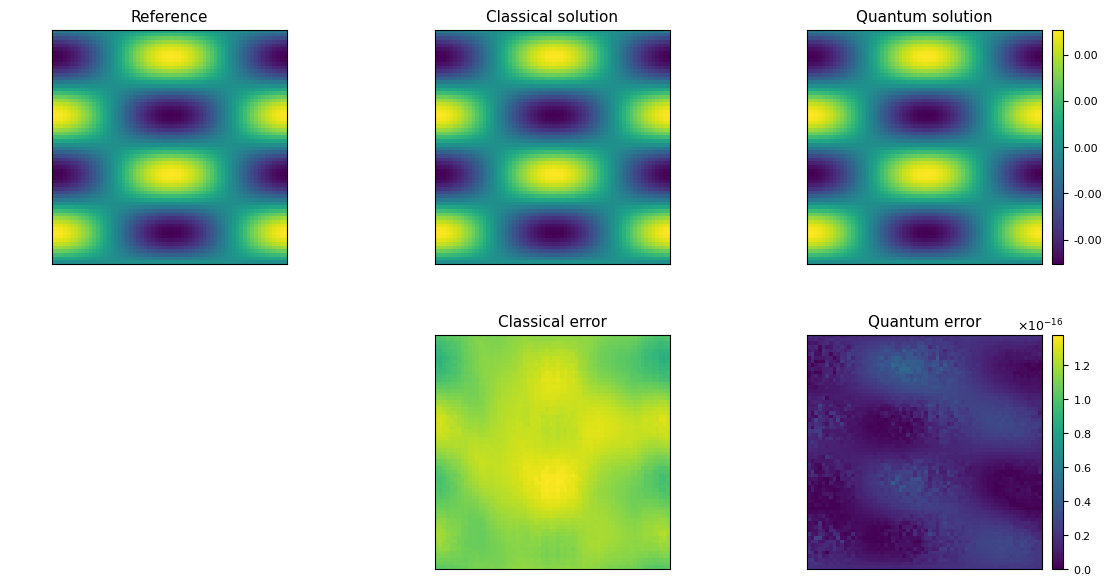

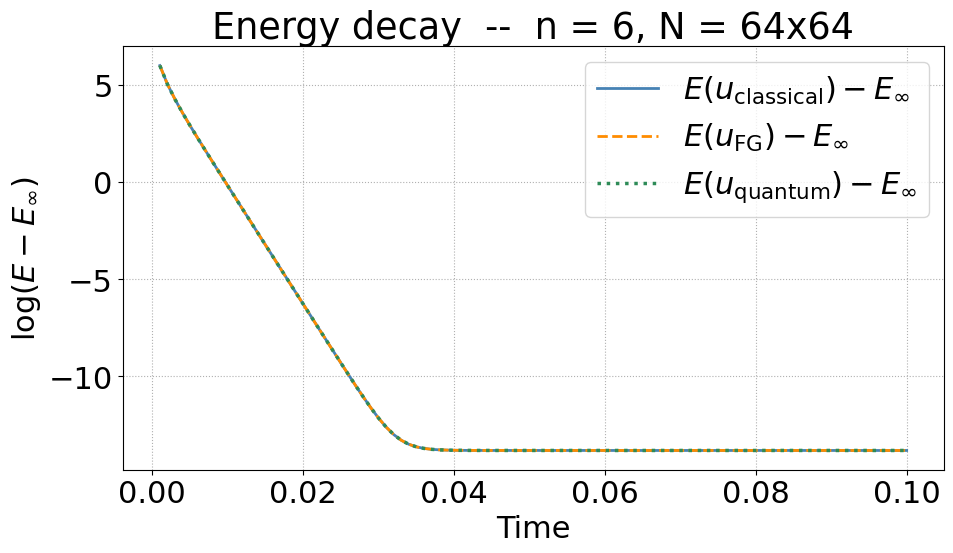


  A configuration : Custom_3_1_1_2
  Matrix:
[[3 1]
 [1 2]]

  Building inverse elliptic operator...



  Building quantum circuit...


/tmp/ipykernel_4725/1420793317.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
/tmp/ipykernel_4725/1420793317.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...



  Time stepping...



  ───────────────────────────────────────────
  Classical error : 7.426214e-14
  Quantum error   : 5.649436e-14
  H5 Data saved:  result_diffusion_A_configs/Custom_3_1_1_2_results.h5


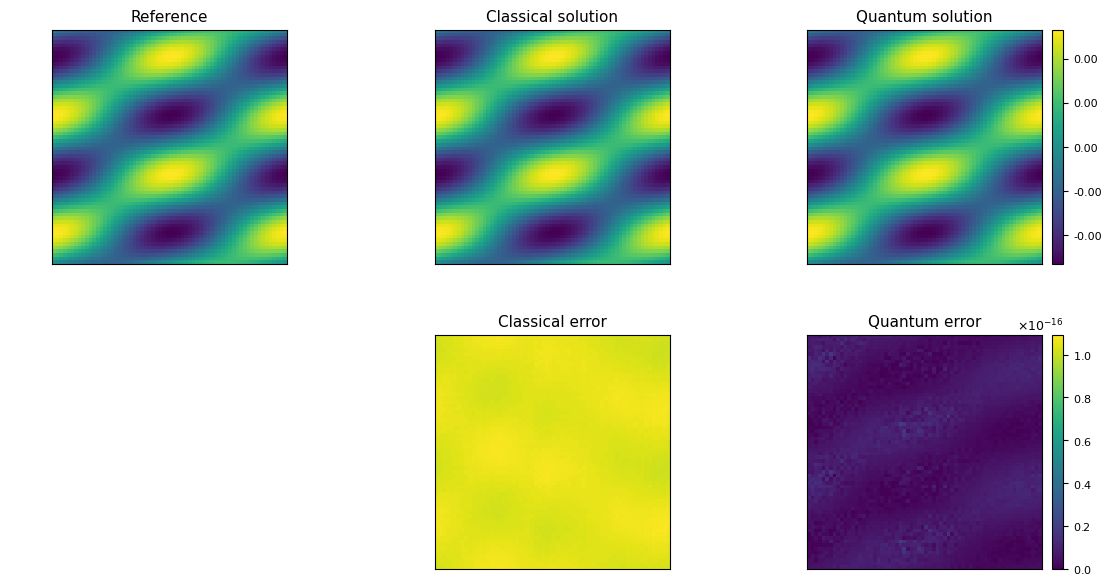

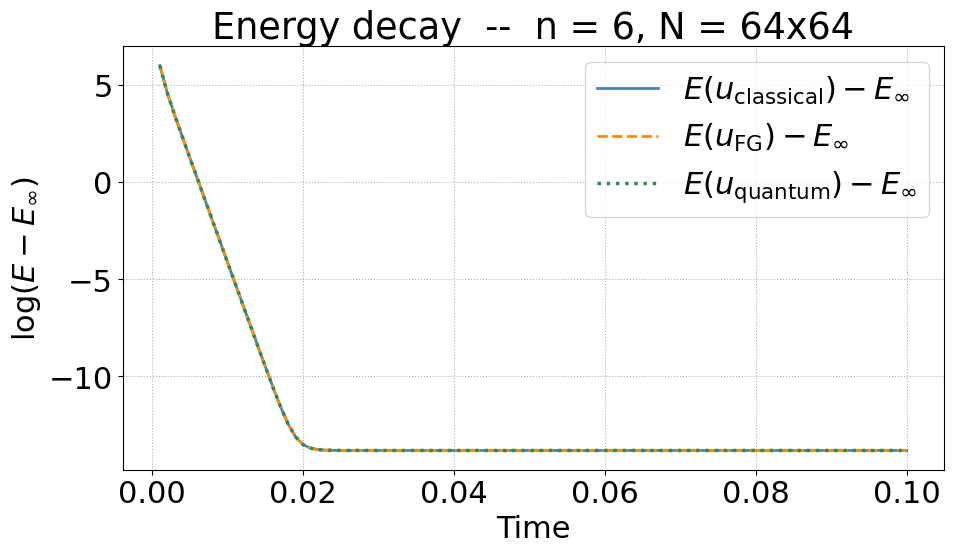


  A configuration : Custom_10_0_0_1
  Matrix:
[[10  0]
 [ 0  1]]

  Building inverse elliptic operator...



  Building quantum circuit...


/tmp/ipykernel_4725/1420793317.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
/tmp/ipykernel_4725/1420793317.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...



  Time stepping...



  ───────────────────────────────────────────
  Classical error : 1.599106e-13
  Quantum error   : 1.230977e-13
  H5 Data saved:  result_diffusion_A_configs/Custom_10_0_0_1_results.h5


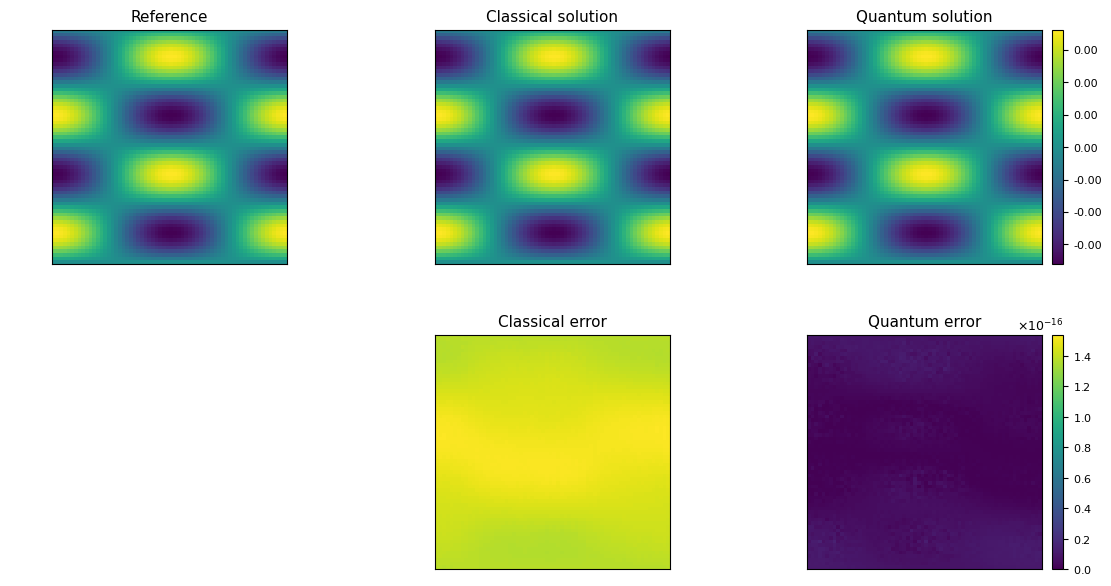

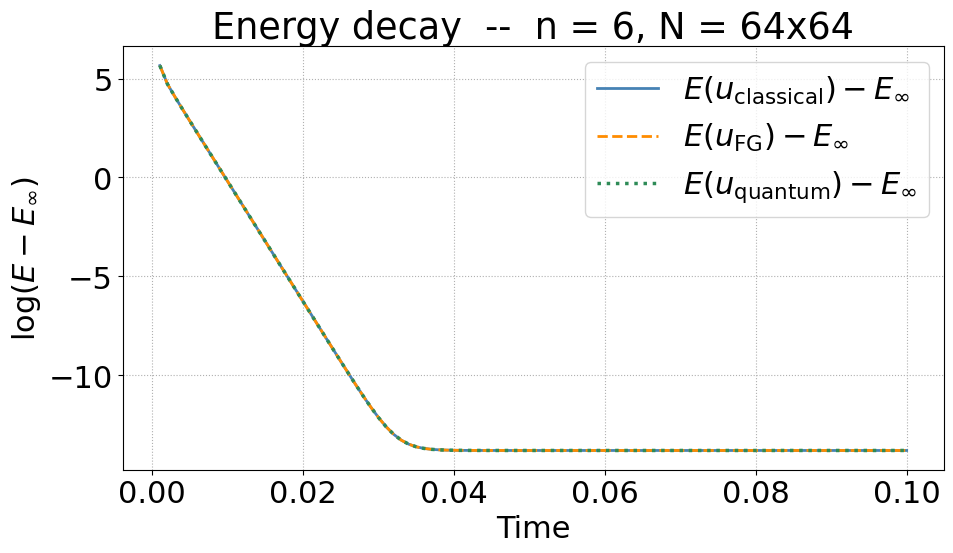


  A configuration : Custom_100_0_0_1
  Matrix:
[[100   0]
 [  0   1]]

  Building inverse elliptic operator...



  Building quantum circuit...


/tmp/ipykernel_4725/1420793317.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
/tmp/ipykernel_4725/1420793317.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...



  Time stepping...



  ───────────────────────────────────────────
  Classical error : 1.285118e-12
  Quantum error   : 9.437274e-13
  H5 Data saved:  result_diffusion_A_configs/Custom_100_0_0_1_results.h5


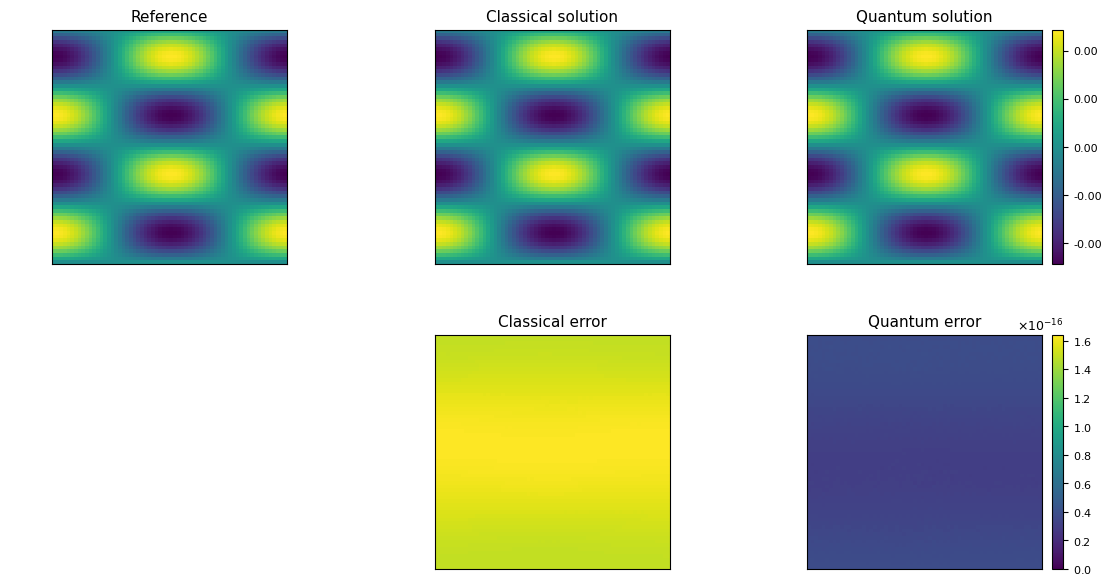

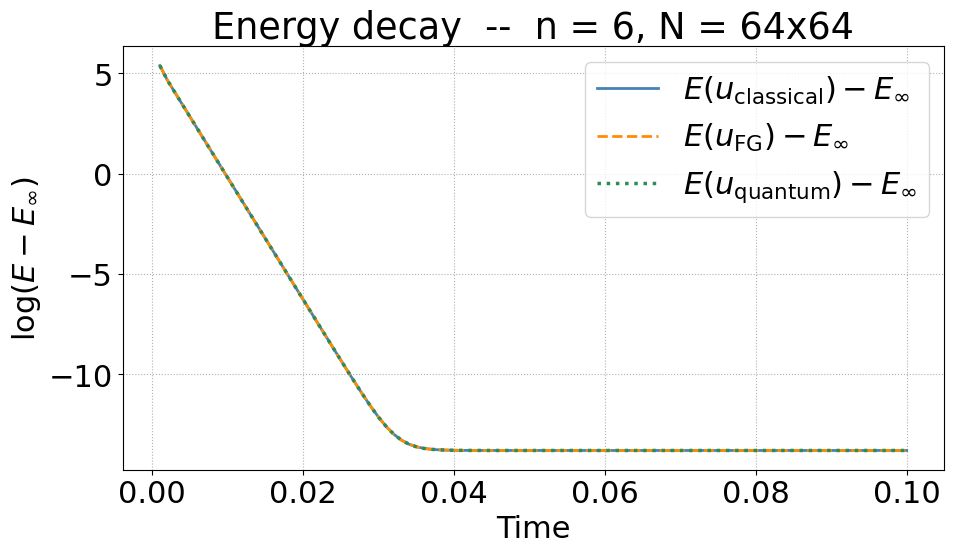


  A configuration : Custom_100_0_0_01
  Matrix:
[[100.    0. ]
 [  0.    0.1]]

  Building inverse elliptic operator...



  Building quantum circuit...


/tmp/ipykernel_4725/1420793317.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
/tmp/ipykernel_4725/1420793317.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...



  Time stepping...



  ───────────────────────────────────────────
  Classical error : 4.343996e-14
  Quantum error   : 1.371668e-13
  H5 Data saved:  result_diffusion_A_configs/Custom_100_0_0_01_results.h5


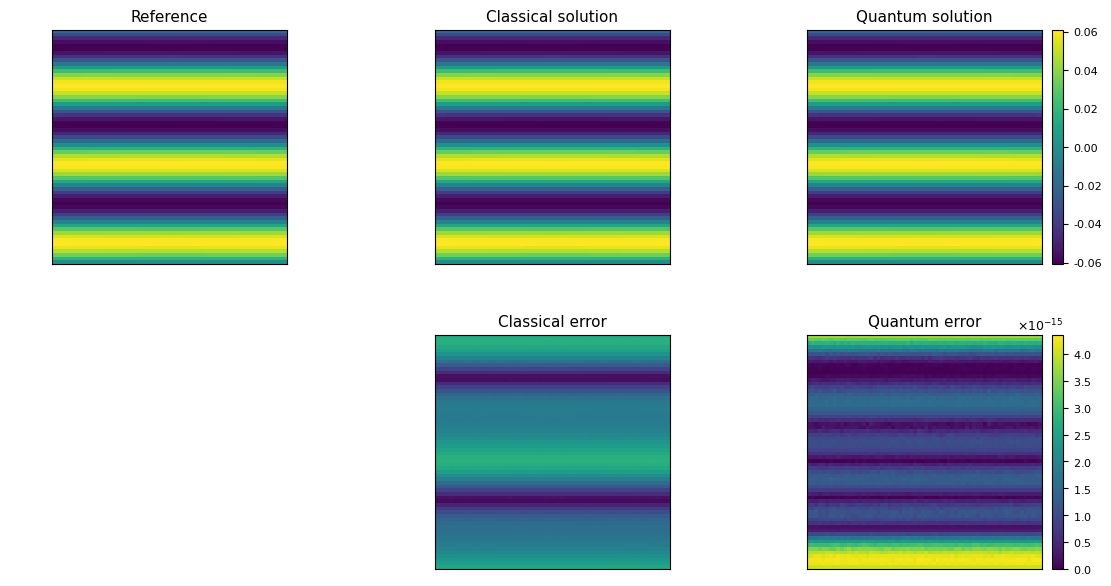

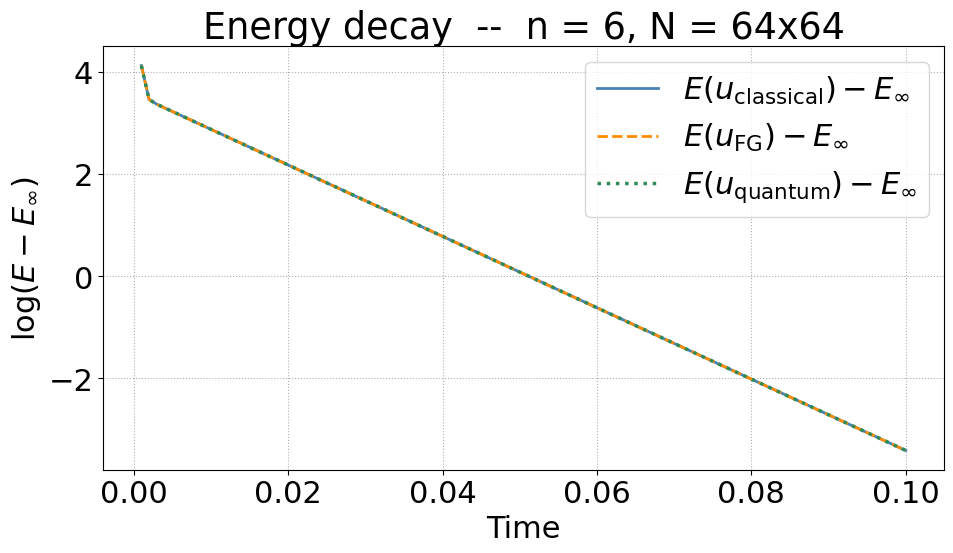


  A configuration : Custom_100000_0_0_1
  Matrix:
[[100000      0]
 [     0      1]]

  Building inverse elliptic operator...



  Building quantum circuit...


/tmp/ipykernel_4725/1420793317.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
/tmp/ipykernel_4725/1420793317.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...



  Time stepping...



  ───────────────────────────────────────────
  Classical error : 1.236105e-09
  Quantum error   : 9.401828e-10
  H5 Data saved:  result_diffusion_A_configs/Custom_100000_0_0_1_results.h5


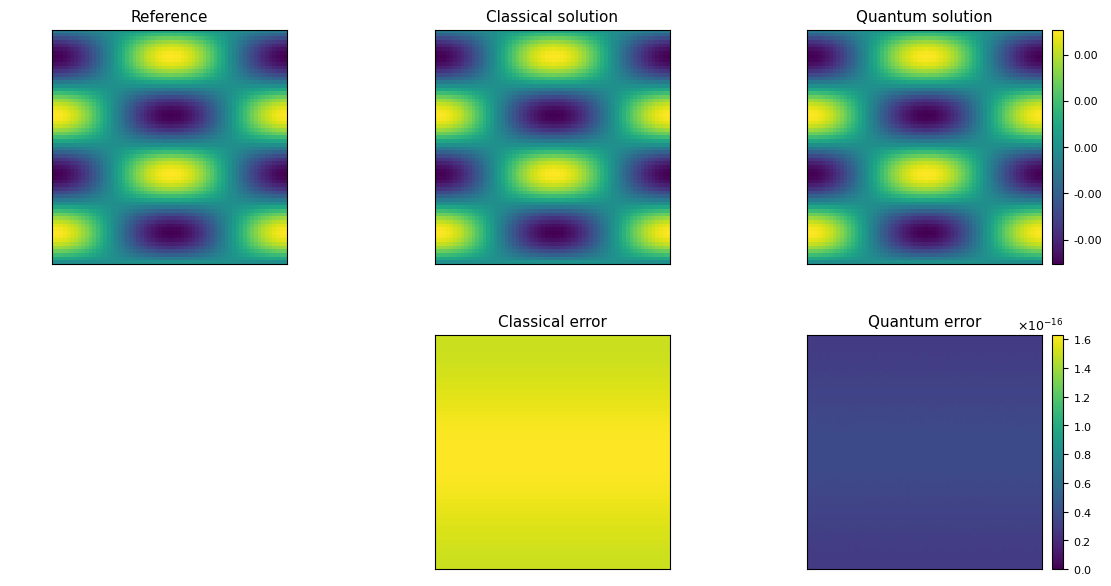

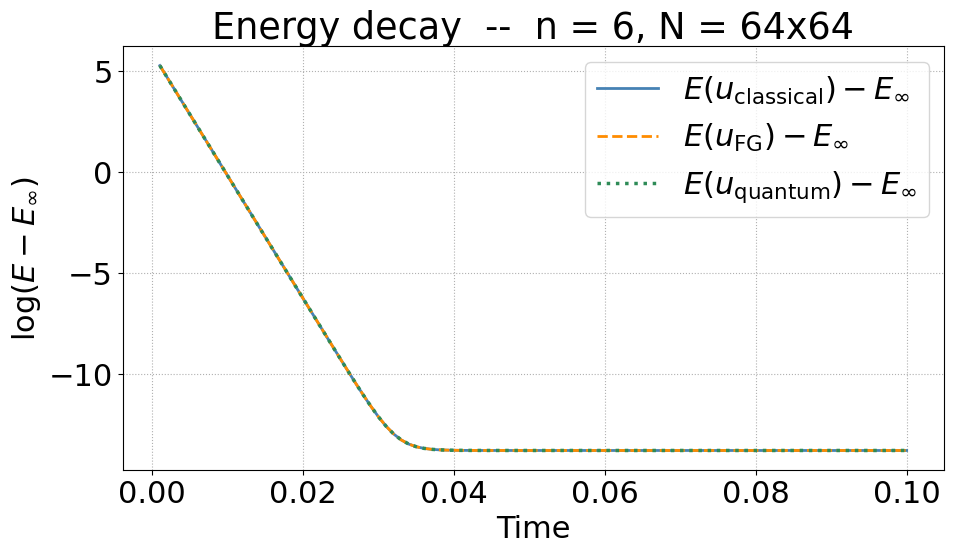


  All done! Results saved in: 'result_diffusion_A_configs/'


In [13]:
import os
import h5py
import numpy as np

# ── A configurations ───────────────────────────────────────────────────────────
A_configs = [
    {'label': 'Identity',             'matrix': np.array([[1,      0  ], [0,    1   ]])},
    {'label': 'Custom_3_1_1_2',       'matrix': np.array([[3,      1  ], [1,    2   ]])},
    {'label': 'Custom_10_0_0_1',      'matrix': np.array([[10,     0  ], [0,    1   ]])},
    {'label': 'Custom_100_0_0_1',     'matrix': np.array([[100,    0  ], [0,    1   ]])},
    {'label': 'Custom_100_0_0_01',    'matrix': np.array([[100,    0  ], [0,    0.1 ]])},
    {'label': 'Custom_100000_0_0_1',  'matrix': np.array([[100000, 0  ], [0,    1   ]])},
]


# ── Updated Output Directory ──────────────────────────────────────────────────
out_dir = "result_diffusion_A_configs"
os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({'font.size': 22})

for cfg in A_configs:
    label = cfg['label']
    print(f"\n{'='*55}")
    print(f"  A configuration : {label}")
    print(f"  Matrix:\n{cfg['matrix']}")
    print(f"{'='*55}")

    # ── Update global A ──
    A = cfg['matrix']

    @jax.vmap
    @jax.vmap
    def A_vec(u):
        return A @ u

    # ── Build inverse elliptic operator ──
    print("\n  Building inverse elliptic operator...")
    inverse_Elliptic = spectralFilter(N_x)
    cond_number = float(np.linalg.cond(inverse_Elliptic))
    
    # ── Build quantum circuit ──
    print("\n  Building quantum circuit...")
    qc, alpha = build_circuit(inverse_Elliptic, n)
    mat = extract_unitary(qc)

    # ── Time stepping ──
    print("\n  Time stepping...")
    block_size    = 2 ** (d * n)
    leading_block = mat[:block_size, :block_size]

    u_theo    = u_init(xs, ys)
    u_spec    = u_init(xs, ys)
    u_quantum = u_init(xs, ys)
    
    energy_spec    = []
    energy_FG      = []
    energy_quantum = []

    # Reference Calculations
    u_ref  = solver_Elliptic(f)
    u_ref  = u_ref.real
    E_ref  = energy(u_ref, f(xs, ys), N_x)
    f_vals = f(xs, ys)

    for _ in range(steps):
        u_theo    = iterative_heat(u_theo, f_vals, N_x, dt=dt)
        u_spec    = iterative_heat_FG(u_spec, f_vals, dt=dt).real
        u_quantum = iterative_heat_QC(u_quantum, f_vals, dt=dt)
        
        # Energy calculations (relative to E_ref)
        energy_spec.append(energy(u_spec, f_vals, N_x) - E_ref + 1e-6)
        energy_FG.append(energy(u_spec, f_vals, N_x) - E_ref + 1e-6)
        energy_quantum.append(energy(u_quantum.real, f_vals, N_x) - E_ref + 1e-6)

    u_quantum       = u_quantum.reshape(N_x, N_x)
    error_classical = float(np.linalg.norm(u_spec - u_theo) / np.linalg.norm(u_theo))
    error_quantum   = float(np.linalg.norm(u_quantum - u_theo) / np.linalg.norm(u_theo))

    print(f"\n  {'─'*43}")
    print(f"  Classical error : {error_classical:.6e}")
    print(f"  Quantum error   : {error_quantum:.6e}")

    # ── Save results to HDF5 file ─────────────────────────────────────
    h5_path = os.path.join(out_dir, f"{label}_results.h5")
    with h5py.File(h5_path, 'w') as hf:
        # Final Iterative Solutions
        hf.create_dataset('u_theoretical', data=np.array(u_theo).real)
        hf.create_dataset('u_classical',   data=np.array(u_spec).real)
        hf.create_dataset('u_quantum',     data=np.array(u_quantum).real)
        
        # Reference Data
        hf.create_dataset('u_ref',         data=np.array(u_ref).real)        
        # Energy Trajectories
        hf.create_dataset('energy_spec',    data=np.array(energy_spec))
        hf.create_dataset('energy_FG',      data=np.array(energy_FG))
        hf.create_dataset('energy_quantum', data=np.array(energy_quantum))
        
        # Matrix and Metadata
        hf.create_dataset('matrix_A',      data=cfg['matrix'])
        hf.attrs['E_ref']            = E_ref
        hf.attrs['condition_number'] = cond_number
        hf.attrs['error_classical']  = error_classical
        hf.attrs['error_quantum']    = error_quantum
        hf.attrs['label']            = label
        
    print(f"  H5 Data saved:  {h5_path}")

    # ── Save Figures ──
    path_sol = os.path.join(out_dir, f"{label}_solutions_errors.png")
    plot_solutions_and_errors(n, N_x, xs, ys, u_theo, u_spec, u_quantum.real,
                              steps, dt, save_path=path_sol)

    path_energy = os.path.join(out_dir, f"{label}_energy.png")
    plot_energy(n, N_x, energy_spec, energy_FG, energy_quantum, steps, dt,
                save_path=path_energy)

print(f"\n{'='*55}")
print(f"  All done! Results saved in: '{out_dir}/'")
print(f"{'='*55}")